## A First Design

Welcome to Ledidi! This first tutorial is a gentle, self-contained introduction that runs entirely on a CPU in a few seconds, with nothing to download. The later tutorials use real genomics models (BPNet, Enformer, Malinois) that require downloading model files, but here we use a tiny "toy oracle" so you can focus on the mechanics of Ledidi itself.

Ledidi turns any differentiable model that scores a sequence into a sequence *editor*. You give it three things — an oracle model, a starting sequence, and the output you want the oracle to produce — and it designs a small set of edits to the sequence that achieve that output. Let's see it in action.

In [1]:
import torch

from ledidi import ledidi

import matplotlib.pyplot as plt

### The oracle

Our oracle scores how well a sequence matches the AP-1 transcription factor motif, `TGACTCA`. It slides the motif across the one-hot encoded sequence with a 1D convolution and returns the single best match. A perfect match anywhere in the sequence scores 7 (the length of the motif); a random sequence scores much lower.

Any differentiable PyTorch model that maps a one-hot sequence of shape `(batch, 4, length)` to a prediction can be used in place of this one — that is the whole point of Ledidi.

In [2]:
motif = "TGACTCA"
weights = torch.zeros(1, 4, len(motif))
for i, char in enumerate(motif):
	weights[0, "ACGT".index(char), i] = 1.0

class MotifScore(torch.nn.Module):
	def forward(self, X):
		return torch.nn.functional.conv1d(X, weights).amax(dim=-1)

model = MotifScore()

### The starting sequence

Ledidi edits one-hot encoded sequences: float tensors of shape `(1, 4, length)` with the four channels ordered `A, C, G, T`. Let's generate a random 50 bp sequence to start from and check what the oracle predicts for it.

In [3]:
torch.manual_seed(0)
idxs = torch.randint(0, 4, (1, 50))
X = torch.zeros(1, 4, 50).scatter_(1, idxs.unsqueeze(1), 1.0)

model(X)

tensor([[5.]])

A low score, as expected — a random sequence is unlikely to contain the AP-1 motif. Now let's ask Ledidi to fix that.

### Designing edits

The desired output `y_bar` is a tensor of shape `(1, n_outputs)`. Our oracle has a single output and we want a perfect motif match, so `y_bar = [[7.0]]`. We pass the model, the starting sequence, and the desired output to `ledidi`.

We set `device="cpu"` because the default is `"cuda"` (pass `"cpu"` explicitly on a machine without a GPU), and `random_state=0` so the run is reproducible without disturbing the global torch RNG. With `verbose=True` (the default) Ledidi prints one line before optimization (`iter=I`), one every `report_iter` iterations, and one at the end (`iter=F`).

In [4]:
y_bar = torch.tensor([[7.0]])
X_hat = ledidi(model, X, y_bar, device="cpu", random_state=0)
X_hat.shape

iter=I	input_loss=0.0	output_loss= 4.0	total_loss= 4.0	time=0.0


iter=100	input_loss=1.875	output_loss=0.125	total_loss=0.3125	time=0.7045
iter=F	input_loss= 2.0	output_loss= 0.0	total_loss= 0.2	time=0.7135


torch.Size([16, 4, 50])

`ledidi` returns a batch of designed sequences with shape `(batch_size, 4, length)`. The `batch_size` (16 by default) sequences are each sampled independently from the single weight matrix Ledidi learned, so they are variations on the same underlying design.

### Did it work?

Let's decode the first designed sequence back into a string and check that the motif is now present.

In [5]:
def decode(seq):  # seq is a single (4, length) one-hot sequence
	return "".join("ACGT"[c] for c in seq.argmax(dim=0))

designed = decode(X_hat[0])
print(designed)
print("Contains TGACTCA:", "TGACTCA" in designed)

ATCATTTTCTCGATGAAAGCGTTGACTCAACATATCGTTAGTACTCTTGT
Contains TGACTCA: True


### What did it change?

The real value of Ledidi is that it makes the *fewest* edits it can. Rather than overwriting a whole stretch of the sequence, it finds the cheapest place to introduce the motif. Let's compare the starting sequence to the first design and list exactly which positions changed.

In [6]:
seq = X_hat[0]
positions = torch.where((X[0] != seq).any(dim=0))[0]
for p in positions:
	before = "ACGT"[X[0, :, p].argmax()]
	after  = "ACGT"[seq[:, p].argmax()]
	print(f"position {p.item()}: {before} -> {after}")

position 26: C -> T
position 28: C -> A


Just a handful of edits — the ones needed to complete a `TGACTCA` at the spot in the random sequence that was already closest to it. Each of the `batch_size` designs is sampled independently, so a different design may carry slightly different edits.

### Watching the optimization

Passing `return_history=True` also returns a dictionary recording the input loss (the average number of edits) and the output loss (distance to the target) at each iteration. The `plot_loss` helper in `ledidi.plot` draws both curves straight from this dictionary, putting the output loss on the left axis and the input loss on the right since the two are on different scales. Looking at these two curves is the best way to build intuition for what Ledidi is doing: it first rapidly acquires edits to drop the output loss, then slowly sheds unnecessary edits to drop the input loss.

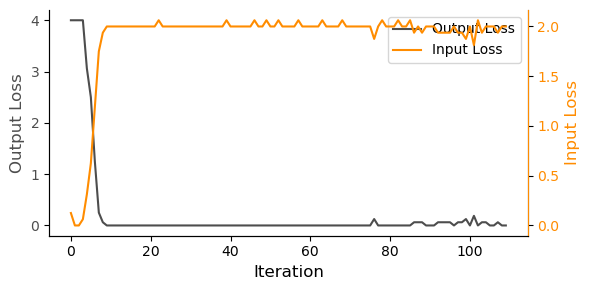

In [7]:
from ledidi.plot import plot_loss

X_hat, history = ledidi(model, X, y_bar, device="cpu", random_state=0,
	return_history=True, verbose=False)

plt.figure(figsize=(6, 3))
plot_loss(history)
plt.tight_layout()
plt.show()

### Where to go next

That is the entire Ledidi workflow: pick an oracle, choose a starting sequence and a desired output, and read off the designed edits. Everything in the later tutorials builds on these same three ingredients.

- **Tutorial 1** runs this workflow on a real BPNet model that predicts GATA2 binding.
- **Tutorial 2** adds hard constraints (masks) and soft priors to control *where* edits may be made.
- **Tutorial 3** covers in-painting — letting Ledidi fill in a region freely.
- **Tutorial 4** uses several models at once.
- **Tutorials 5 and 6** cover affinity catalogs and custom loss functions.
- **Tutorial 7** shows how to validate a design by checking it against independent models and attributions.
- **Tutorial 8** revisits this toy oracle to show how to fit the weights once and then sample many designs cheaply.

For reference, the documentation also has pages on the exact [input and output formats](../input_output.rst), the [key parameters](../parameters.rst) worth tuning, and a [FAQ](../faq.rst) covering reproducibility and common errors.